In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
import itertools
import re
from collections import Counter
import seaborn as sns

In [2]:
# It tells Matplotlib's mathtext engine to render math upright (roman) instead of the default italics — 
# without needing to wrap your labels in \mathrm{} or edit the list.
plt.rcParams['mathtext.default'] = 'regular' 

In [3]:
import pickle 
with open(r'data/processed/all_c_elegans_weighted_graphs.pkl', 'rb') as file:
    all_c_elegans_weighted_graphs = pickle.load(file)

In [4]:
for graph in all_c_elegans_weighted_graphs:
    print(list(nx.selfloop_edges(graph)))

[]
[]
[]
[]
[]
[]
[]
[]


In [5]:
stage_labels = ['L1-0', 'L1-5', 'L1-8', 'L1-16', 'L2', 'L3', 'Ad_1', 'Ad_2']

In [6]:
stage_labels_plot = ['L1$_{0h}$', 'L1$_{5h}$', 'L1$_{8h}$', 'L1$_{16h}$', 'L2', 'L3', 'Ad$^{1}$', 'Ad$^{2}$']

### Core decomposition

**The following core decomposition codes are written after a confirming the results of a 'parent' k-core function with that of networkx.***

In [7]:
def kin_k_core_decomposition(G):
    k_cores = {}
    G_k_core = G.copy()

    while G_k_core.number_of_nodes() > 0:
        min_k = min(dict(G_k_core.in_degree()).values())
        k_cores[min_k] = list(G_k_core.nodes())
        
        to_remove = [node for node, in_degree in G_k_core.in_degree() if in_degree <= min_k]
        
        while to_remove:
            G_k_core.remove_nodes_from(to_remove)
            to_remove = [node for node, in_degree in G_k_core.in_degree() if in_degree <= min_k]

    return k_cores

In [8]:
def kout_k_core_decomposition(G):
    k_cores = {}
    G_k_core = G.copy()

    while G_k_core.number_of_nodes() > 0:
        min_k = min(dict(G_k_core.out_degree()).values())
        k_cores[min_k] = list(G_k_core.nodes())
        
        to_remove = [node for node, out_degree in G_k_core.out_degree() if out_degree <= min_k]
        
        while to_remove:
            G_k_core.remove_nodes_from(to_remove)
            to_remove = [node for node, out_degree in G_k_core.out_degree() if out_degree <= min_k]

    return k_cores

#### Similarly, s-core functions are below

In [9]:
def kin_s_core_decomposition(G):
    s_cores = {}
    G_s_core = G.copy()

    while G_s_core.number_of_nodes() > 0:
        min_s = min(dict(G_s_core.in_degree(weight='weight')).values())
        s_cores[min_s] = list(G_s_core.nodes())
        
        to_remove = [node for node, strength in G_s_core.in_degree(weight='weight') if strength <= min_s]
        
        while to_remove:
            G_s_core.remove_nodes_from(to_remove)
            to_remove = [node for node, strength in G_s_core.in_degree(weight='weight') if strength <= min_s]

    return s_cores

In [10]:
def kout_s_core_decomposition(G):
    s_cores = {}
    G_s_core = G.copy()

    while G_s_core.number_of_nodes() > 0:
        min_s = min(dict(G_s_core.out_degree(weight='weight')).values())
        s_cores[min_s] = list(G_s_core.nodes())
        
        to_remove = [node for node, strength in G_s_core.out_degree(weight='weight') if strength <= min_s]
        
        while to_remove:
            G_s_core.remove_nodes_from(to_remove)
            to_remove = [node for node, strength in G_s_core.out_degree(weight='weight') if strength <= min_s]

    return s_cores

**Finding and saving all layers of core decomposition for each graph using all 4 types of core decomposition methods. To be used for correlation with communities (using shells/occupancy), As well as to study the layers themselves.**

In [11]:
def convert_inner_lists_to_sets(nested_dict):
    for outer_key, inner_dict in nested_dict.items():
        for inner_key, value_list in inner_dict.items():
            inner_dict[inner_key] = set(value_list)
    return nested_dict


In [12]:
all_kin_k_cores_all_graphs, all_kout_k_cores_all_graphs, all_kin_s_cores_all_graphs, all_kout_s_cores_all_graphs = {}, {}, {}, {}
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    
    # finding all types of cores 
    kin_k_cores = kin_k_core_decomposition(graph)
    kout_k_cores = kout_k_core_decomposition(graph)
    kin_s_cores = kin_s_core_decomposition(graph)
    kout_s_cores = kout_s_core_decomposition(graph)

    # storing the cores
    all_kin_k_cores_all_graphs[i] = kin_k_cores
    all_kout_k_cores_all_graphs[i] = kout_k_cores
    all_kin_s_cores_all_graphs[i] = kin_s_cores
    all_kout_s_cores_all_graphs[i] = kout_s_cores

In [13]:
all_kin_k_cores_all_graphs = convert_inner_lists_to_sets(all_kin_k_cores_all_graphs)
all_kout_k_cores_all_graphs = convert_inner_lists_to_sets(all_kout_k_cores_all_graphs)
all_kin_s_cores_all_graphs = convert_inner_lists_to_sets(all_kin_s_cores_all_graphs)
all_kout_s_cores_all_graphs = convert_inner_lists_to_sets(all_kout_s_cores_all_graphs)

**All cores are stored AFTER the removal of selfloops in the Ad1 stage.**

In [14]:
#with open(r'data/processed/C_elegans_all_layers_kin_kcore_decomposition_all_stages.pkl', 'wb') as file:
    #pickle.dump(all_kin_k_cores_all_graphs, file)

#with open(r'data/processed/C_elegans_all_layers_kout_kcore_decomposition_all_stages.pkl', 'wb') as file:
    #pickle.dump(all_kout_k_cores_all_graphs, file)

#with open(r'data/processed/C_elegans_all_layers_kin_score_decomposition_all_stages.pkl', 'wb') as file:
    #pickle.dump(all_kin_s_cores_all_graphs, file)

#with open(r'data/processed/C_elegans_all_layers_kout_score_decomposition_all_stages.pkl', 'wb') as file:
    #pickle.dump(all_kout_s_cores_all_graphs, file)

In [15]:
with open(r'data/processed/C_elegans_all_layers_kin_kcore_decomposition_all_stages.pkl', 'rb') as file:
    all_kin_k_cores_all_graphs = pickle.load(file)

**k-core results**

In [16]:
kin_k_cores_across_stages = {}
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    kin_k_cores = kin_k_core_decomposition(graph)
    maincorenumber = max(kin_k_cores.keys())
    kin_k_cores_across_stages[i] = set(kin_k_cores[maincorenumber])
    celltypes = dict(Counter([graph.nodes[node]['parent_class_info']['celltype'] for node in kin_k_cores[maincorenumber]]))
    print(celltypes, '\n')

{'Interneuron': 2, 'Motor neuron': 10, 'Modulatory neuron': 1, 'Muscle': 2} 

{'Interneuron': 2, 'Motor neuron': 10, 'Muscle': 3} 

{'Sensory neuron': 10, 'Interneuron': 14, 'Motor neuron': 10, 'Modulatory neuron': 7, 'Muscle': 5, 'Glia': 1} 

{'Interneuron': 2, 'Motor neuron': 10, 'Muscle': 5} 

{'Sensory neuron': 30, 'Modulatory neuron': 14, 'Interneuron': 33, 'Motor neuron': 29, 'Muscle': 21} 

{'Sensory neuron': 30, 'Modulatory neuron': 16, 'Interneuron': 36, 'Motor neuron': 38, 'Muscle': 23, 'Glia': 5} 

{'Sensory neuron': 43, 'Modulatory neuron': 28, 'Interneuron': 40, 'Motor neuron': 38, 'Muscle': 29, 'Glia': 1} 

{'Sensory neuron': 36, 'Modulatory neuron': 25, 'Interneuron': 36, 'Motor neuron': 29, 'Muscle': 22, 'Glia': 2} 



In [17]:
kout_k_cores_across_stages = {}
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    kout_k_cores = kout_k_core_decomposition(graph)
    maincorenumber = max(kout_k_cores.keys())
    kout_k_cores_across_stages[i] = set(kout_k_cores[maincorenumber])
    celltypes = dict(Counter([graph.nodes[node]['parent_class_info']['celltype'] for node in kout_k_cores[maincorenumber]]))
    print(celltypes, '\n')

{'Sensory neuron': 26, 'Modulatory neuron': 11, 'Interneuron': 21, 'Motor neuron': 7} 

{'Sensory neuron': 28, 'Modulatory neuron': 15, 'Interneuron': 28, 'Motor neuron': 8} 

{'Sensory neuron': 34, 'Modulatory neuron': 16, 'Interneuron': 24, 'Motor neuron': 10} 

{'Sensory neuron': 36, 'Modulatory neuron': 16, 'Interneuron': 26, 'Motor neuron': 8} 

{'Sensory neuron': 28, 'Modulatory neuron': 13, 'Interneuron': 23, 'Motor neuron': 5} 

{'Sensory neuron': 24, 'Modulatory neuron': 15, 'Interneuron': 22, 'Motor neuron': 7} 

{'Sensory neuron': 33, 'Modulatory neuron': 23, 'Interneuron': 27, 'Motor neuron': 7} 

{'Sensory neuron': 43, 'Modulatory neuron': 27, 'Interneuron': 29, 'Motor neuron': 11} 



**s-core results**

In [18]:
kin_s_cores_across_stages = {}
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    kin_s_cores = kin_s_core_decomposition(graph)
    maincorenumber = max(kin_s_cores.keys())
    kin_s_cores_across_stages[i] = set(kin_s_cores[maincorenumber])
    celltypes = dict(Counter([graph.nodes[node]['parent_class_info']['celltype'] for node in kin_s_cores[maincorenumber]]))
    print(celltypes, '\n')

{'Interneuron': 2, 'Motor neuron': 6} 

{'Interneuron': 2, 'Motor neuron': 8} 

{'Interneuron': 2, 'Motor neuron': 6} 

{'Interneuron': 2, 'Motor neuron': 6} 

{'Interneuron': 2, 'Motor neuron': 6} 

{'Interneuron': 2, 'Motor neuron': 6} 

{'Interneuron': 2, 'Motor neuron': 7} 

{'Interneuron': 2, 'Motor neuron': 4} 



In [19]:
kout_s_cores_across_stages = {}
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    kout_s_cores = kout_s_core_decomposition(graph)
    maincorenumber = max(kout_s_cores.keys())
    kout_s_cores_across_stages[i] = set(kout_s_cores[maincorenumber])
    celltypes = dict(Counter([graph.nodes[node]['parent_class_info']['celltype'] for node in kout_s_cores[maincorenumber]]))
    print(celltypes, '\n')

{'Sensory neuron': 6, 'Interneuron': 10, 'Motor neuron': 2} 

{'Sensory neuron': 6, 'Interneuron': 13, 'Motor neuron': 4, 'Modulatory neuron': 1} 

{'Interneuron': 2, 'Motor neuron': 2} 

{'Interneuron': 2, 'Motor neuron': 2} 

{'Interneuron': 2, 'Motor neuron': 2} 

{'Interneuron': 3} 

{'Sensory neuron': 16, 'Interneuron': 14, 'Motor neuron': 2, 'Modulatory neuron': 1} 

{'Interneuron': 2} 



**All main cores are stored AFTER the removal of selfloops in the Ad1 stage.** 

In [20]:
#with open(r'data/processed/C_elegans_kout_k_cores_across_stages.pkl', 'wb') as file:
    #pickle.dump(kout_k_cores_across_stages, file)
    
#with open(r'data/processed/C_elegans_kin_k_cores_across_stages.pkl', 'wb') as file:
    #pickle.dump(kin_k_cores_across_stages, file)

In [21]:
#with open(r'data/processed/C_elegans_kin_s_cores_across_stages.pkl', 'wb') as file:
    #pickle.dump(kin_s_cores_across_stages, file)
    
#with open(r'data/processed/C_elegans_kout_s_cores_across_stages.pkl', 'wb') as file:
    #pickle.dump(kout_s_cores_across_stages, file)

In [22]:
with open(r'data/processed/C_elegans_kin_k_cores_across_stages.pkl', 'rb') as file:
    kin_k_cores_across_stages = pickle.load(file)
    
with open(r'data/processed/C_elegans_kout_k_cores_across_stages.pkl', 'rb') as file:
    kout_k_cores_across_stages = pickle.load(file)

In [23]:
with open(r'data/processed/C_elegans_kin_s_cores_across_stages.pkl', 'rb') as file:
    kin_s_cores_across_stages = pickle.load(file)
    
with open(r'data/processed/C_elegans_kout_s_cores_across_stages.pkl', 'rb') as file:
    kout_s_cores_across_stages = pickle.load(file)

celltype_colors = {
    "Sensory neuron": "blue",
    "Modulatory neuron": "red",
    "Interneuron": "green",
    "Motor neuron": "orange",
    'Muscle': 'pink',
    'Glia': 'brown',
    "NA": "gray",
}

In [24]:
celltype_colors = {
    "Sensory neuron": "#f9cef9",
    "Modulatory neuron": "#f9d77b",
    "Interneuron": "#ff887a",
    "Motor neuron": "#b7daf5",
    'Muscle': '#a8f5a2',
    'Glia': 'brown',
    "NA": "gray",
}


In [25]:
celltypes = ['Sensory neuron', 'Modulatory neuron', 'Interneuron', 'Motor neuron', 'Muscle', 'Glia', 'NA']
matrix_kcore_kin = []
for idx, core in kin_k_cores_across_stages.items():
    graph = all_c_elegans_weighted_graphs[idx]
    types = [graph.nodes[node]['parent_class_info'].get("celltype", "NA") for node in core]
    type_count = [types.count(typ) for typ in celltypes]
    matrix_kcore_kin.append(list(type_count))
matrix_kcore_kin = np.array(matrix_kcore_kin)
matrix_kcore_kin

matrix_kcore_kout = []
for idx, core in kout_k_cores_across_stages.items():
    graph = all_c_elegans_weighted_graphs[idx]
    types = [graph.nodes[node]['parent_class_info'].get("celltype", "NA") for node in core]
    type_count = [types.count(typ) for typ in celltypes]
    matrix_kcore_kout.append(list(type_count))
matrix_kcore_kout = np.array(matrix_kcore_kout)
matrix_kcore_kout

array([[26, 11, 21,  7,  0,  0,  0],
       [28, 15, 28,  8,  0,  0,  0],
       [34, 16, 24, 10,  0,  0,  0],
       [36, 16, 26,  8,  0,  0,  0],
       [28, 13, 23,  5,  0,  0,  0],
       [24, 15, 22,  7,  0,  0,  0],
       [33, 23, 27,  7,  0,  0,  0],
       [43, 27, 29, 11,  0,  0,  0]])

In [26]:
matrix_kcore_kin

array([[ 0,  1,  2, 10,  2,  0,  0],
       [ 0,  0,  2, 10,  3,  0,  0],
       [10,  7, 14, 10,  5,  1,  0],
       [ 0,  0,  2, 10,  5,  0,  0],
       [30, 14, 33, 29, 21,  0,  0],
       [30, 16, 36, 38, 23,  5,  0],
       [43, 28, 40, 38, 29,  1,  0],
       [36, 25, 36, 29, 22,  2,  0]])

In [27]:
matrix_score_kin = []
for idx, core in kin_s_cores_across_stages.items():
    graph = all_c_elegans_weighted_graphs[idx]
    types = [graph.nodes[node]['parent_class_info'].get("celltype", "NA") for node in core]
    type_count = [types.count(typ) for typ in celltypes]
    matrix_score_kin.append(list(type_count))
matrix_score_kin = np.array(matrix_score_kin)
matrix_score_kin

matrix_score_kout = []
for idx, core in kout_s_cores_across_stages.items():
    graph = all_c_elegans_weighted_graphs[idx]
    types = [graph.nodes[node]['parent_class_info'].get("celltype", "NA") for node in core]
    type_count = [types.count(typ) for typ in celltypes]
    matrix_score_kout.append(list(type_count))
matrix_score_kout = np.array(matrix_score_kout)
matrix_score_kout

array([[ 6,  0, 10,  2,  0,  0,  0],
       [ 6,  1, 13,  4,  0,  0,  0],
       [ 0,  0,  2,  2,  0,  0,  0],
       [ 0,  0,  2,  2,  0,  0,  0],
       [ 0,  0,  2,  2,  0,  0,  0],
       [ 0,  0,  3,  0,  0,  0,  0],
       [16,  1, 14,  2,  0,  0,  0],
       [ 0,  0,  2,  0,  0,  0,  0]])

In [28]:
kin_k_cores_across_stages

{0: {95, 96, 117, 118, 119, 120, 121, 122, 143, 144, 145, 146, 165, 180, 189},
 1: {95, 96, 117, 118, 119, 120, 121, 122, 143, 144, 145, 146, 183, 188, 191},
 2: {33,
  39,
  40,
  43,
  44,
  45,
  46,
  47,
  48,
  52,
  70,
  77,
  78,
  83,
  84,
  95,
  96,
  97,
  98,
  101,
  103,
  104,
  106,
  107,
  117,
  118,
  119,
  120,
  121,
  122,
  143,
  144,
  145,
  146,
  163,
  164,
  165,
  166,
  174,
  175,
  177,
  181,
  182,
  188,
  193,
  195,
  222},
 3: {95,
  96,
  117,
  118,
  119,
  120,
  121,
  122,
  143,
  144,
  145,
  146,
  180,
  183,
  188,
  191,
  192},
 4: {0,
  2,
  5,
  10,
  11,
  12,
  15,
  21,
  23,
  24,
  30,
  31,
  32,
  33,
  34,
  39,
  40,
  43,
  44,
  45,
  46,
  47,
  48,
  51,
  52,
  53,
  54,
  59,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  89,
  91,
  95,
  96,
  97,
  98,
  99,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  1

In [29]:
core_numbers_kin_kcore = []
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    kin_k_cores = kin_k_core_decomposition(graph)
    maincorenumber = max(kin_k_cores.keys())
    core_numbers_kin_kcore.append(maincorenumber)
    
core_numbers_kout_kcore = []
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    kout_k_cores = kout_k_core_decomposition(graph)
    maincorenumber = max(kout_k_cores.keys())
    core_numbers_kout_kcore.append(maincorenumber)

In [30]:
core_numbers_kin_score = []
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    kin_s_cores = kin_s_core_decomposition(graph)
    maincorenumber = max(kin_s_cores.keys())
    core_numbers_kin_score.append(maincorenumber)
    
core_numbers_kout_score = []
for i, graph in enumerate(all_c_elegans_weighted_graphs):
    kout_s_cores = kout_s_core_decomposition(graph)
    maincorenumber = max(kout_s_cores.keys())
    core_numbers_kout_score.append(maincorenumber)

In [31]:
print(core_numbers_kin_kcore, core_numbers_kout_kcore)
print(core_numbers_kin_score, core_numbers_kout_score)

[3, 3, 3, 3, 3, 3, 4, 5] [3, 3, 3, 3, 4, 4, 6, 5]
[7, 10, 15, 23, 28, 31, 38, 55] [6, 8, 11, 15, 20, 19, 24, 48]


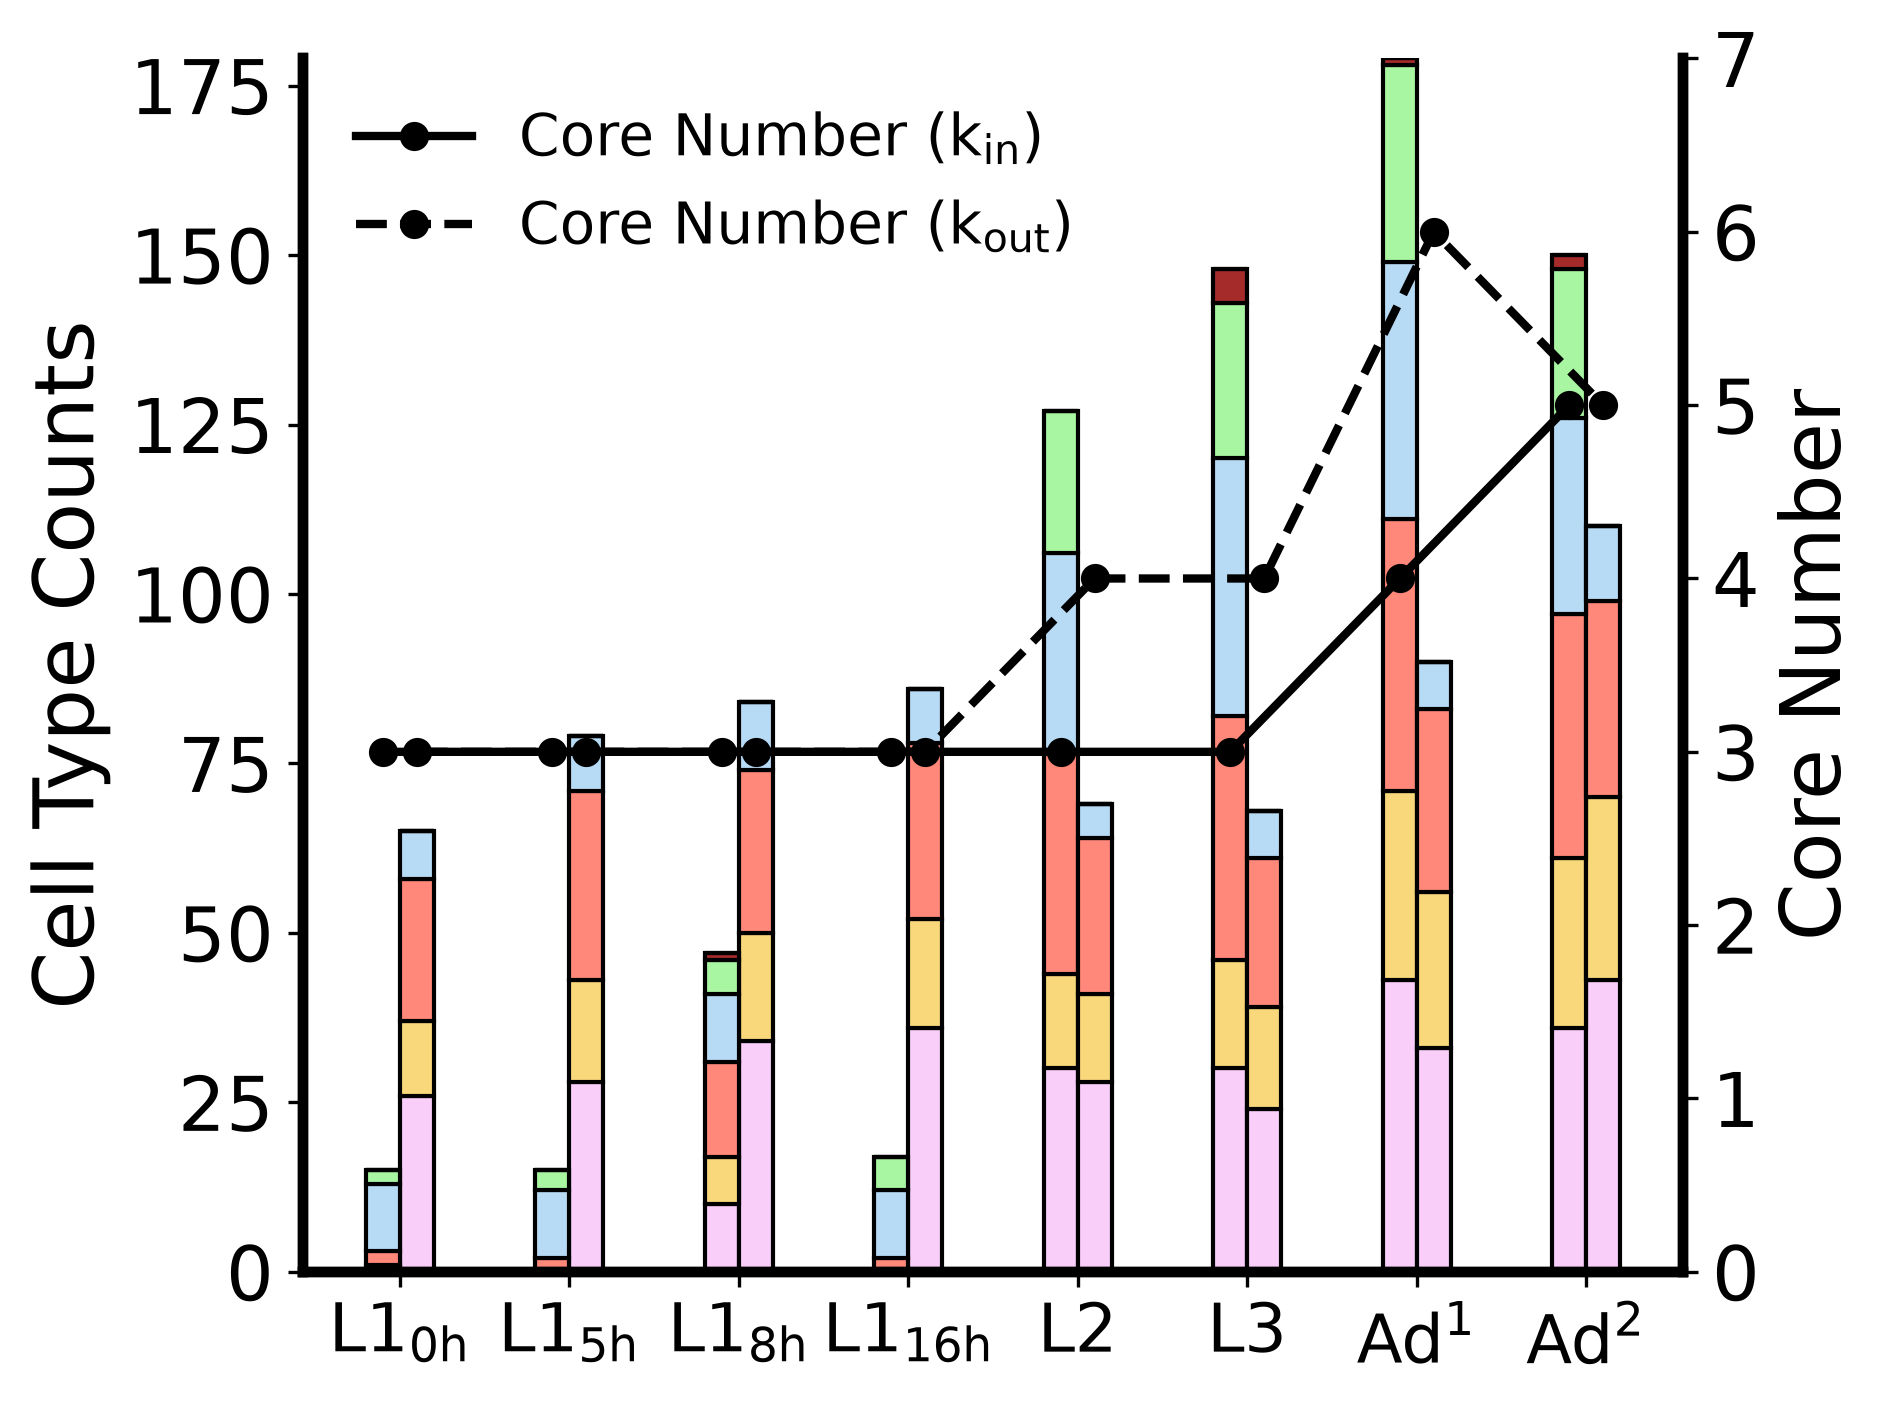

In [32]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(dpi=300)

x = np.arange(len(stage_labels_plot))
bar_width = 0.20
offsets = [-bar_width/2, +bar_width/2]

# --- stacked bars ---
bottoms_kin = np.zeros(len(stage_labels_plot))
bottoms_kout = np.zeros(len(stage_labels_plot))

for i, celltype in enumerate(celltypes):
    ax.bar(
        x + offsets[0],
        matrix_kcore_kin[:, i],
        width=bar_width,
        bottom=bottoms_kin,
        color=celltype_colors[celltype],
        edgecolor='black'
    )
    bottoms_kin += matrix_kcore_kin[:, i]

    ax.bar(
        x + offsets[1],
        matrix_kcore_kout[:, i],
        width=bar_width,
        bottom=bottoms_kout,
        color=celltype_colors[celltype],
        edgecolor='black'
    )
    bottoms_kout += matrix_kcore_kout[:, i]

# --- left axis ---
ax.set_xticks(x)
ax.set_xticklabels(stage_labels_plot)
ax.set_ylabel("Cell Type Counts", fontsize=20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=18)

# --- right axis: core-number lines ---
axr = ax.twinx()

line1, = axr.plot(
    x + offsets[0],
    core_numbers_kin_kcore,
    marker='o',
    color='black',
    linewidth=2,
    label="Core Number ($k_{in}$)"
)

line2, = axr.plot(
    x + offsets[1],
    core_numbers_kout_kcore,
    marker='o',
    linestyle='--',
    color='black',
    linewidth=2,
    label="Core Number ($k_{out}$)"
)

axr.set_ylabel("Core Number", fontsize=20)
axr.tick_params(axis='y', labelsize=18)
axr.yaxis.set_major_locator(plt.MultipleLocator(1))
axr.set_ylim(
    0,
    max(np.max(core_numbers_kin_kcore), np.max(core_numbers_kout_kcore)) + 1
)

# --- aesthetics ---
ax.spines['top'].set_visible(False)
axr.spines['top'].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(2.5)
for spine in axr.spines.values():
    spine.set_linewidth(2.5)

# --- ONLY line legend ---
axr.legend(frameon=False, fontsize=14, loc='upper left')

plt.tight_layout()
plt.show()


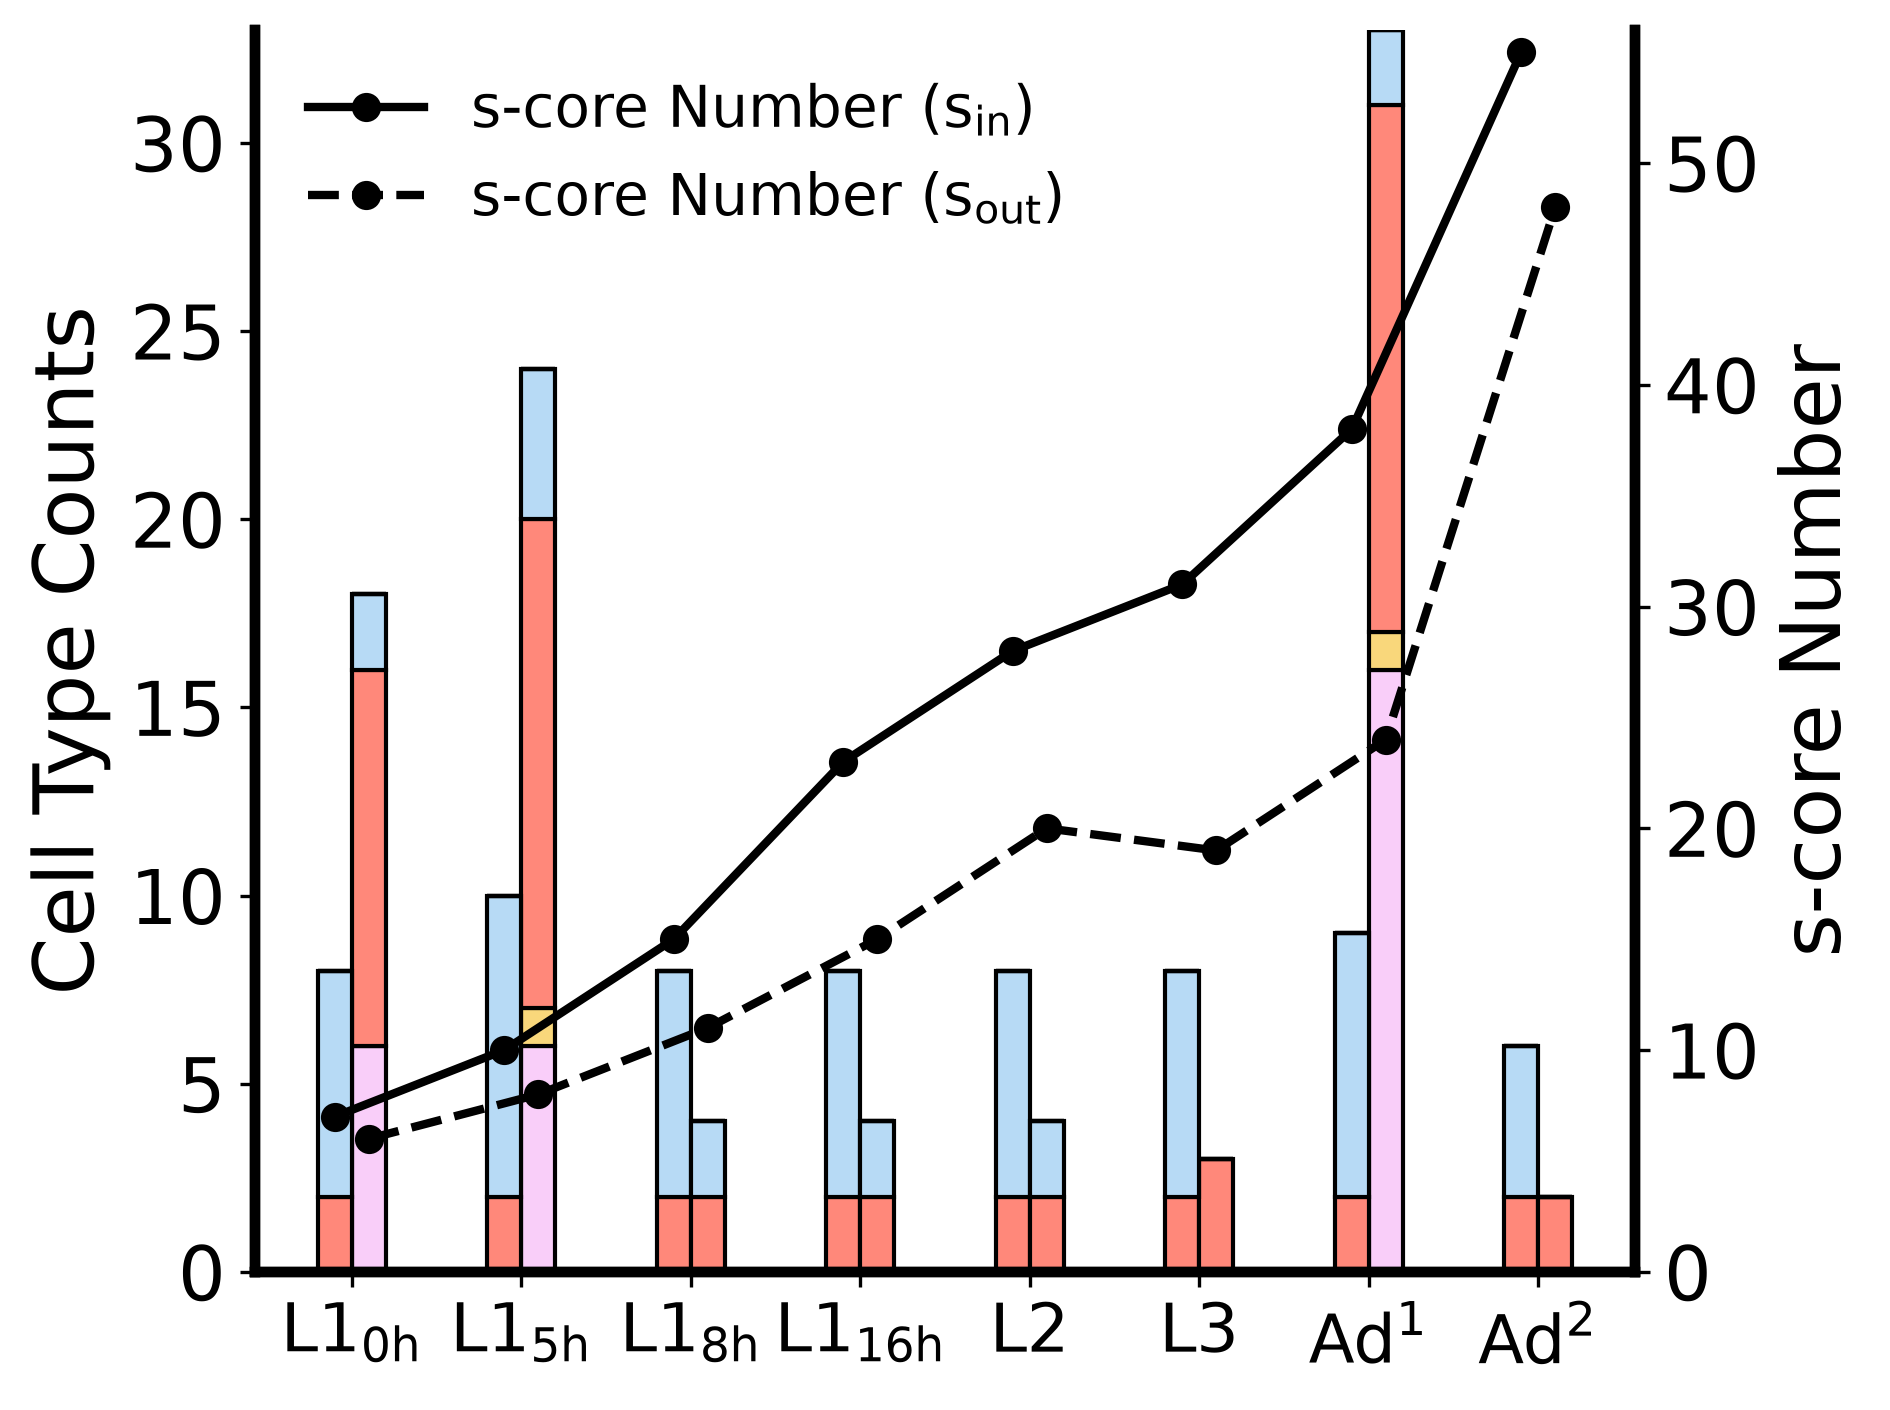

In [33]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(dpi=300)

x = np.arange(len(stage_labels_plot))
bar_width = 0.20
offsets = [-bar_width/2, +bar_width/2]

# --- stacked bars ---
bottoms_kin = np.zeros(len(stage_labels_plot))
bottoms_kout = np.zeros(len(stage_labels_plot))

for i, celltype in enumerate(celltypes):
    ax.bar(
        x + offsets[0],
        matrix_score_kin[:, i],
        width=bar_width,
        bottom=bottoms_kin,
        color=celltype_colors[celltype],
        edgecolor='black'
    )
    bottoms_kin += matrix_score_kin[:, i]

    ax.bar(
        x + offsets[1],
        matrix_score_kout[:, i],
        width=bar_width,
        bottom=bottoms_kout,
        color=celltype_colors[celltype],
        edgecolor='black'
    )
    bottoms_kout += matrix_score_kout[:, i]

# --- left axis ---
ax.set_xticks(x)
ax.set_xticklabels(stage_labels_plot)
ax.set_ylabel("Cell Type Counts", fontsize=20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=18)

# --- right axis: s-core numbers ---
axr = ax.twinx()

axr.plot(
    x + offsets[0],
    core_numbers_kin_score,
    marker='o',
    color='black',
    linewidth=2,
    label="s-core Number ($s_{in}$)"
)

axr.plot(
    x + offsets[1],
    core_numbers_kout_score,
    marker='o',
    linestyle='--',
    color='black',
    linewidth=2,
    label="s-core Number ($s_{out}$)"
)

axr.set_ylabel("s-core Number", fontsize=20)
axr.tick_params(axis='y', labelsize=18)

axr.set_ylim(
    0,
    max(np.max(core_numbers_kin_score), np.max(core_numbers_kout_score)) + 1
)

# --- aesthetics ---
ax.spines['top'].set_visible(False)
axr.spines['top'].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(2.5)
for spine in axr.spines.values():
    spine.set_linewidth(2.5)

# --- ONLY line legend ---
axr.legend(frameon=False, fontsize=14, loc='upper left')

plt.tight_layout()
plt.show()


### Radial Map

In [34]:
union_graph = nx.compose_all(all_c_elegans_weighted_graphs) 
print(union_graph)

DiGraph with 223 nodes and 3665 edges


In [35]:
def classify_neurons(core_dict):
    """Classifies neurons into persistent, recurrent, and transient categories."""
    neuron_counts = {}  # Track stages each neuron shows up in

    for stage, neurons in core_dict.items():
        for neuron in neurons:
            neuron_counts[neuron] = neuron_counts.get(neuron, 0) + 1

    persistent = {n for n, count in neuron_counts.items() if count == 8}
    recurrent = {n for n, count in neuron_counts.items() if 2 <= count < 8}
    transient = {n for n, count in neuron_counts.items() if count == 1}

    return persistent, recurrent, transient

# applying classification to each core type
persistent_in_kcore, recurrent_in_kcore, transient_in_kcore = classify_neurons(kin_k_cores_across_stages)
persistent_out_kcore, recurrent_out_kcore, transient_out_kcore = classify_neurons(kout_k_cores_across_stages)
persistent_in_score, recurrent_in_score, transient_in_score = classify_neurons(kin_s_cores_across_stages)
persistent_out_score, recurrent_out_score, transient_out_score = classify_neurons(kout_s_cores_across_stages)

In [36]:
with open(r'data/raw/C_elegans_Adult_Communities_from_Emmons_Paper_based_on_chemical_gap_jn.txt', 'r') as file:
    Emmons_paper_communities_dict = dict()
    for line in file:
        if len(line.rstrip()) != 0 and line.rstrip().startswith('Community'):
            key = line.rstrip()
        elif len(line.rstrip()) != 0 and not line.rstrip().startswith('Community'):
            Emmons_paper_communities_dict[key] = set(item.lstrip() for item in line.rstrip().split(','))
            

In [37]:
from matplotlib.patches import Patch

# Behavior mapping: community name → simplified label
community_behavior_map = {
    'Community 1-Locomotion': 'Locomotion',
    'Community 2-Foraging': 'Foraging',
    'Community 3-Amphids, Chemosensation, Odor sensation': 'Chemosensation',
    'Community 4-Aerotaxis and ???': 'Aerotaxis+',
    'Community 5-Pharynx': 'Pharynx',
    'Community 6-Vulval muscles': 'Vulva',
    'Community 7-Defecation': 'Defecation',
    'Community 8-Uterine muscles': 'Uterus',
    'Community 9-Proprioception, ventral cord interneurons, posterior motor system': 'Posterior motor',
    'Community 10-Sex': 'Sex'
}

# Colors for each behavior
behavior_colors = {
    'Locomotion': '#08306b',      # deep blue
    'Foraging': '#8b0000',        # dark red
    'Chemosensation': '#00441b',  # dark green
    'Aerotaxis+': '#3f007d',       # purple
    'Pharynx': '#6a3d9a',
    'Sex': '#b15928',
    'Vulva': '#67000d',
    'Uterus': '#238b45',
    'Defecation': '#54278f',
    'Posterior motor': '#045a8d'
}


In [38]:
for comm, neurons in Emmons_paper_communities_dict.items():
    renamed_neurons = set()
    for neuron in neurons:
        if 'BWM' in neuron:
            dov = neuron[0]
            lor = neuron[4]
            number = neuron[5:]
            if len(number) == 1:
                number = '0' + number
            renamed = 'BWM-' + dov.upper() + lor + number
            renamed_neurons.add(renamed)
            #print(neuron, '-->', renamed)
        else:
            renamed_neurons.add(neuron)
    Emmons_paper_communities_dict[comm] = renamed_neurons

In [39]:
# neuron_id → behavior label
neuron_to_behavior = {}
for community, neurons in Emmons_paper_communities_dict.items():
    behavior = community_behavior_map.get(community)
    for neuron in neurons:
        neuron_to_behavior[neuron] = behavior

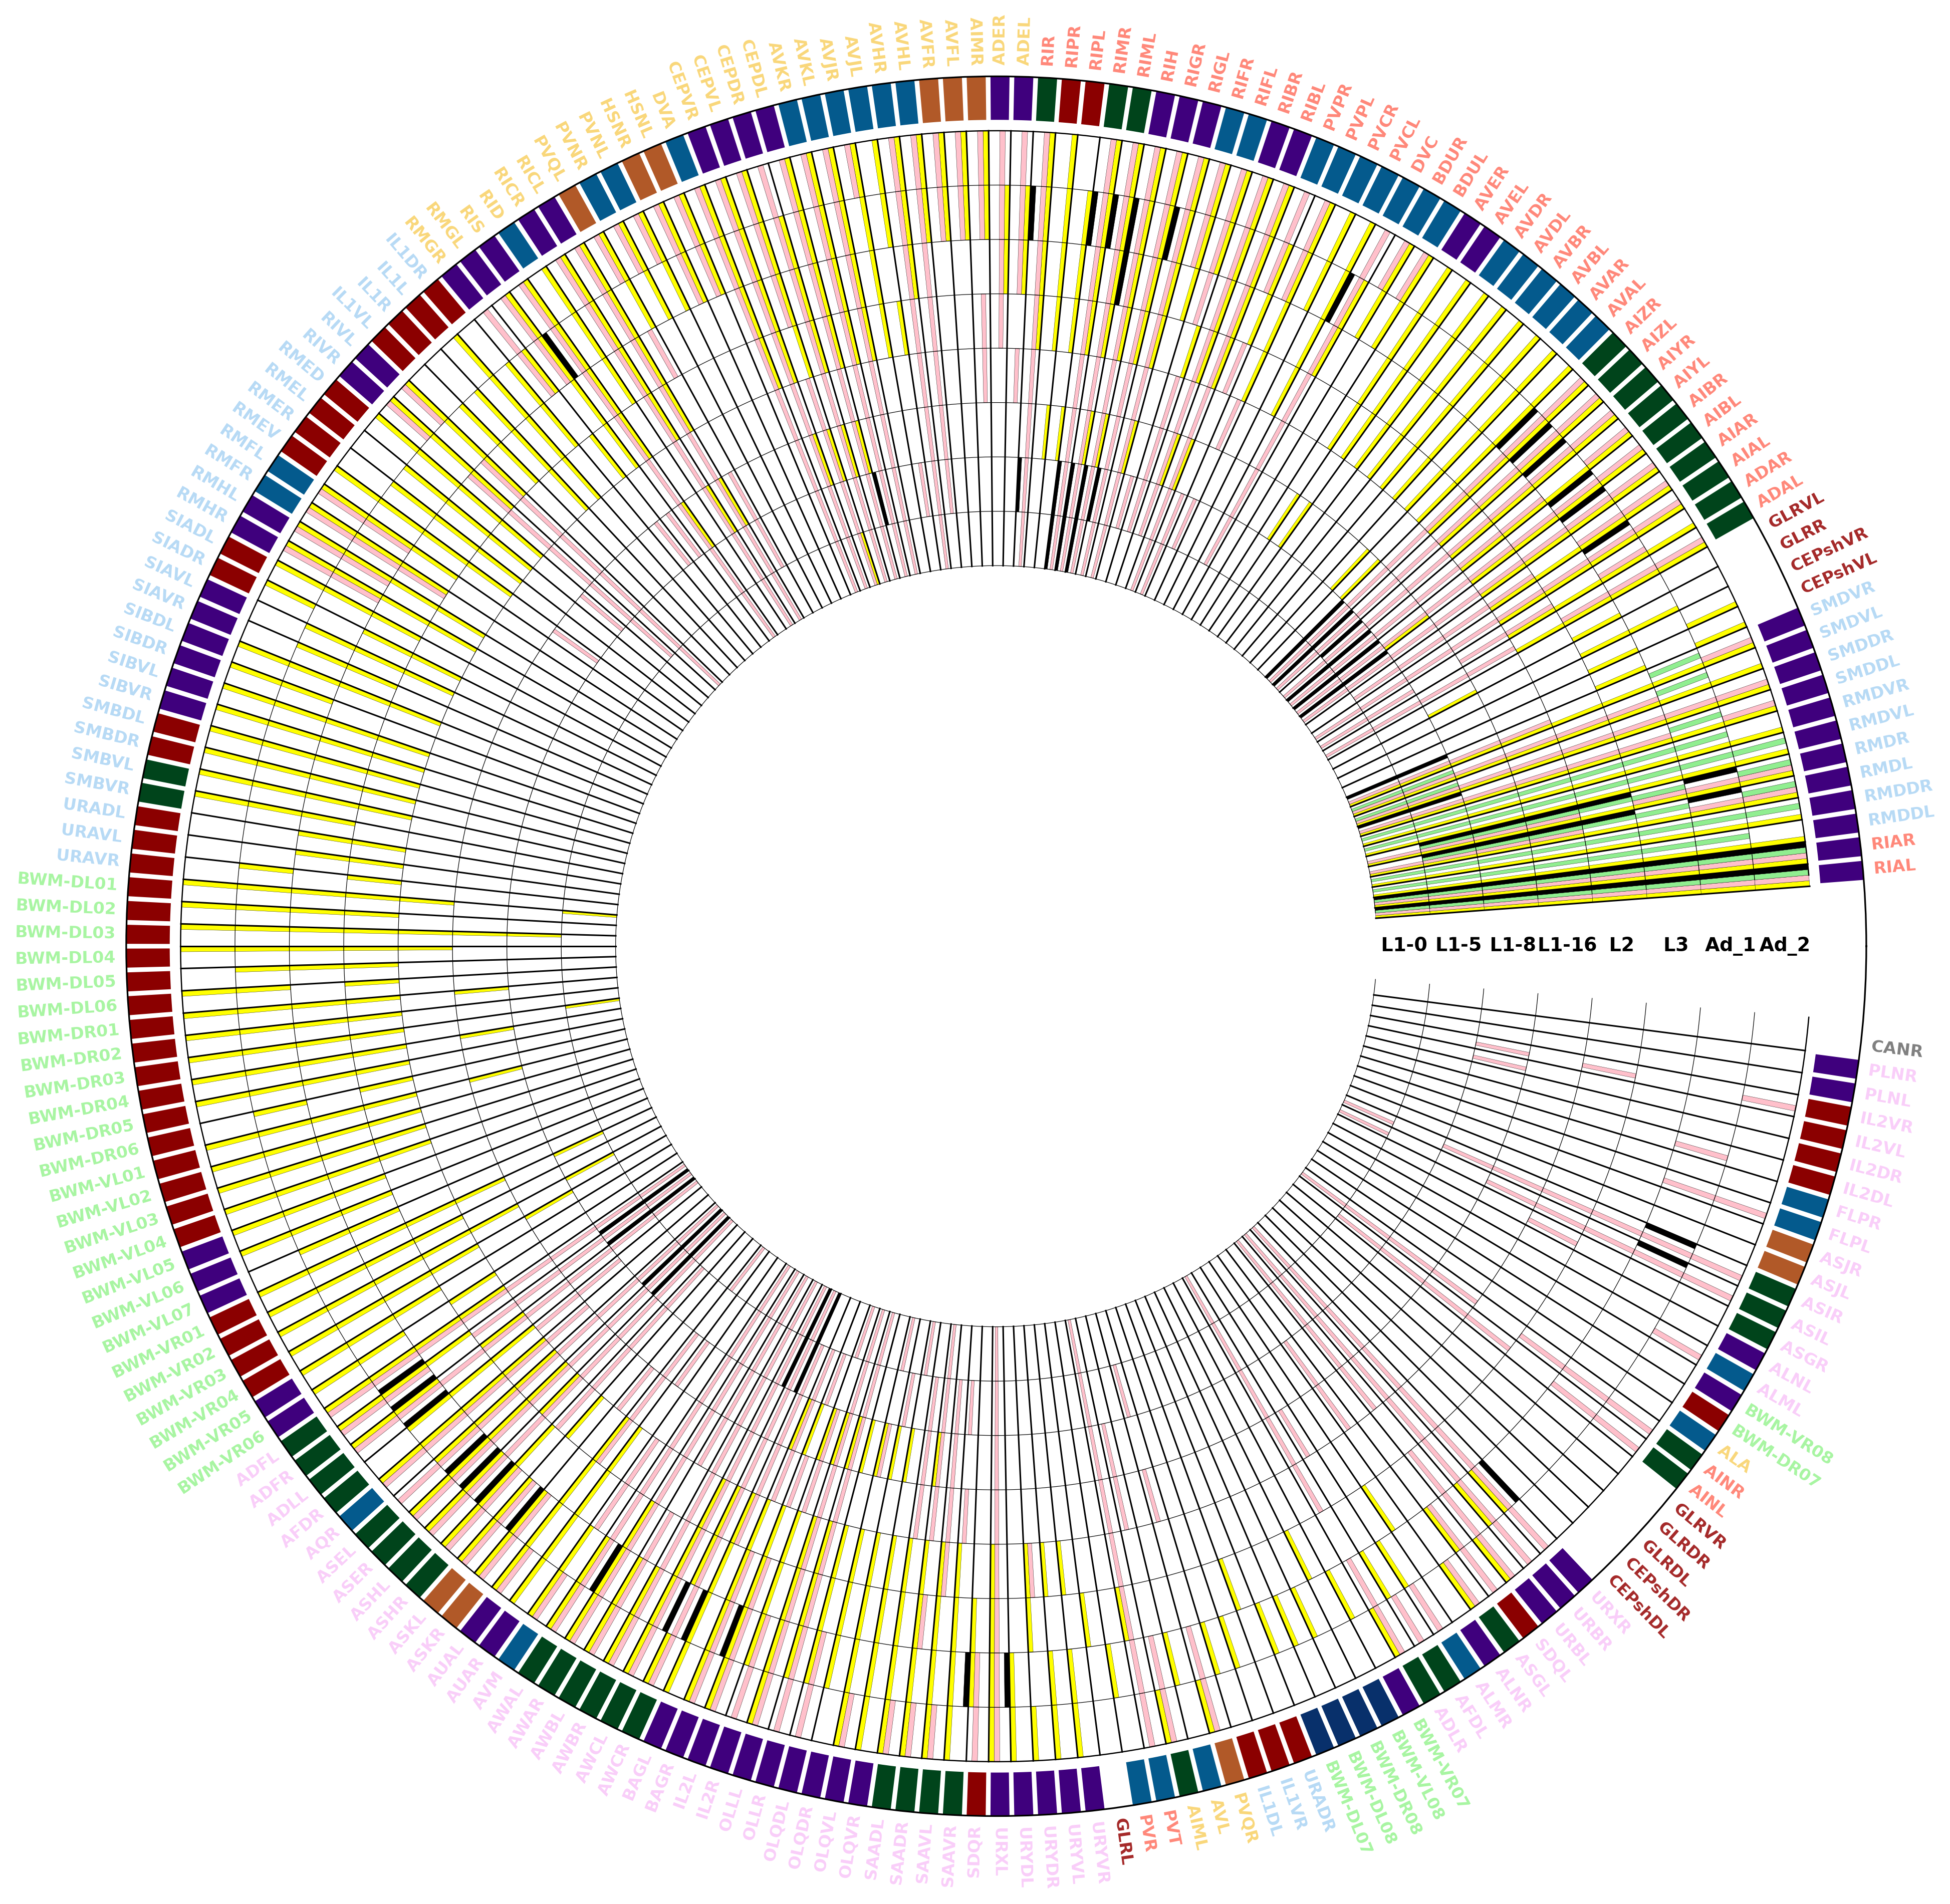

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Step 1: Build stage presence matrix
all_neurons = set()
for stage_set in kin_k_cores_across_stages.values():
    all_neurons.update(stage_set)

# Include neurons not in any core
all_neurons.update(union_graph.nodes)

neuron_stage_presence = {}
for neuron in all_neurons:
    presence = [int(neuron in kin_k_cores_across_stages.get(i, set())) for i in range(8)]
    neuron_stage_presence[neuron] = presence

# Step 2: Categorize neurons
neuron_categories = defaultdict(list)
for neuron, presence in neuron_stage_presence.items():
    total = sum(presence)
    if total == 8:
        cat = 'Persistent'
    elif total >= 2:
        cat = 'Recurrent'
    elif total == 1:
        cat = 'Transient'
    else:
        cat = 'Never in core'
    neuron_categories[cat].append(neuron)

# Step 3: Sort neurons within each category by celltype and name
ordered_neurons = []
for category in ['Persistent', 'Recurrent', 'Transient', 'Never in core']:
    temp = []
    for neuron in neuron_categories[category]:
        info = union_graph.nodes[neuron].get('parent_class_info', {})
        celltype = info.get('celltype', 'Unknown') if isinstance(info, dict) else 'Unknown'
        name = union_graph.nodes[neuron].get('specific_class', neuron)
        temp.append((celltype, name, neuron))
    for _, _, neuron in sorted(temp):
        ordered_neurons.append(neuron)

# Step 4: Plotting setup
num_neurons = len(ordered_neurons)
num_stages = 8

gap_angle = np.deg2rad(10)  # 10° gap at top center
theta_start = gap_angle / 2
theta_end = 2 * np.pi - gap_angle / 2

theta = np.linspace(theta_start, theta_end, num_neurons, endpoint=False)
width = (theta_end - theta_start) / num_neurons

# Push plot outward by increasing the starting radius
start_radius = 4 
stage_cell_height = 0.5  # each bar is now slightly shorter
radii = start_radius + np.arange(num_stages) * stage_cell_height

fig, ax = plt.subplots(figsize=(13, 13), dpi=300, subplot_kw=dict(polar=True))

# Grid rings drawn only over the arc span (excluding the top gap)
arc_theta = np.linspace(theta_start, theta_end, 500)
for r in radii:
    ax.plot(arc_theta, [r]*len(arc_theta), color='black', lw=0.3)


# Step 5: Draw bars for presence
method_colors = {
    'In k-core': "yellow",
    'Out k-core': "pink",
    'In s-core': "lightgreen",
    'Out s-core': "black"
}

# earlier colors were: "deepskyblue","palevioletred","palegreen","darkgrey"

method_dicts = {
    'In k-core': kin_k_cores_across_stages,
    'Out k-core': kout_k_cores_across_stages,
    'In s-core': kin_s_cores_across_stages,
    'Out s-core': kout_s_cores_across_stages
}

for idx, neuron in enumerate(ordered_neurons):
    for stage_idx in range(num_stages):
        for m_idx, method in enumerate(method_dicts):
            if neuron not in method_dicts[method].get(stage_idx, set()):
                continue

# Correct center-based alignment for method wedges
            cell_center = theta[idx]                   # this is the center of the neuron’s angular space
            method_width = width / 4                   # each wedge is 1/4th the neuron cell
            offset = (m_idx - 1.5) * method_width      # center m_idx = 0 to 3 symmetrically around cell_center
            method_theta = cell_center + offset        # center of this wedge

            ax.bar(method_theta, stage_cell_height, bottom=radii[stage_idx],
                   width=method_width, color=method_colors[method],
                   edgecolor='black', linewidth=0.1)


# Draw radial dividers between neurons
for idx in range(num_neurons):
    angle = theta[idx] - width / 2  # left edge of the cell
    ax.plot([angle, angle], [radii[0], radii[-1] + stage_cell_height],
            color='black', lw=0.75, zorder=5)

# Step 6: Add radial labels
# Adjusted label radius to push text clearly outside the outermost ring

celltype_colors = {
    "Sensory neuron": "#f9cef9",
    "Modulatory neuron": "#f9d77b",
    "Interneuron": "#ff887a",
    "Motor neuron": "#b7daf5",
    "Muscle": "#a8f5a2",
    "Glia": "brown",
    "NA": "gray",
}

label_radius = radii[-1] + 1.1

for idx, neuron in enumerate(ordered_neurons):
    label = union_graph.nodes[neuron].get('specific_class', neuron)
    info = union_graph.nodes[neuron].get('parent_class_info', {})
    celltype = info.get('celltype', 'NA') if isinstance(info, dict) else 'NA'
    color = celltype_colors.get(celltype, 'black')

    angle_rad = theta[idx]
    angle_deg = np.rad2deg(angle_rad)

    if 90 <= angle_deg <= 270:
        rotation = angle_deg + 180
        ha = 'right'
    else:
        rotation = angle_deg
        ha = 'left'

    ax.text(angle_rad, label_radius, label,
            rotation=rotation, ha=ha, va='center',
            fontsize=8, fontweight='bold', clip_on=False, rotation_mode='anchor', zorder=10,
            color=color)
    
# Drawing a circle to visually mark the outer boundary of the last stage's cells
outer_ring_radius = radii[-1] + stage_cell_height  # top of last bar ring
ax.plot(arc_theta, [outer_ring_radius] * len(arc_theta), color='black', lw=0.6)

# Draw one tick per neuron indicating behavior (outermost layer)
tick_base = radii[-1] + 1.4  # just outside the neuron labels
tick_height = 0.2

for idx, neuron in enumerate(ordered_neurons):
    spclass = union_graph.nodes[neuron].get('specific_class', neuron)
    behavior = neuron_to_behavior.get(spclass)
    if behavior in behavior_colors:
        color = behavior_colors[behavior]
        ax.bar(theta[idx], tick_height-1, bottom=tick_base, width=width * 0.8,
               color=color, edgecolor='none')

# Step 7: Stage labels
for r, label in zip(radii + 0.25, stage_labels):
    #ax.text(0, r, label, ha='center', va='center', fontsize=9)
    ax.text(0, r, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Final adjustments
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(0.5, radii[-1] + 1)

#ax.set_title("In-degree k-core Neuron Participation Across Development", fontsize=14)

plt.tight_layout()
plt.show()


In [41]:
method_colors = {
    '$k_{in}$-core': "yellow",
    '$k_{out}$-core': "pink",
    '$s_{in}$-core': "lightgreen",
    '$s_{out}$-core': "black"
}

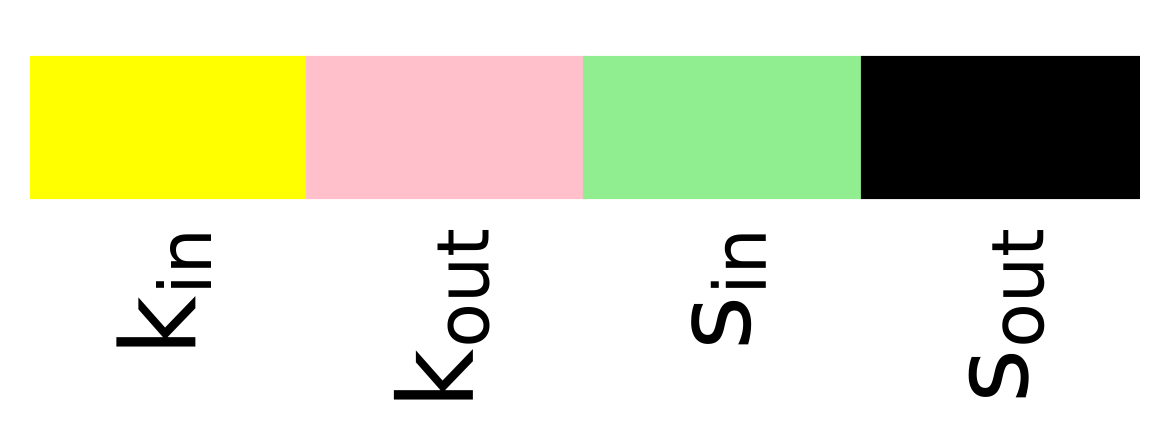

In [42]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(len(method_colors), 1.5), dpi=300)
ax.axis('off')

for i, (method, color) in enumerate(method_colors.items()):
    ax.add_patch(Rectangle((i, 0), 1, 1, color=color))
    ax.text(i + 0.5, -0.2, method.split('-')[0], ha='center', va='top', fontsize=25, rotation=90)

ax.set_xlim(0, len(method_colors))
ax.set_ylim(-0.5, 1.2)
plt.tight_layout()
plt.show()


### Rectangular Color Map

In [48]:
all_core_neurons = set().union(*kin_k_cores_across_stages.values(),
                               *kout_k_cores_across_stages.values(),
                               *kin_s_cores_across_stages.values(),
                               *kout_s_cores_across_stages.values())

other_neurons = {n for n in union_graph.nodes() if n not in all_core_neurons}

In [49]:
# initialise result dict
neuron_core_counts = {}

for neuron in all_core_neurons:
    neuron_core_counts[neuron] = {
        'kin': 0,
        'kout': 0,
        'sin': 0,
        'sout': 0
    }

    for stage in range(8):
        if neuron in kin_k_cores_across_stages[stage]:
            neuron_core_counts[neuron]['kin'] += 1
        if neuron in kout_k_cores_across_stages[stage]:
            neuron_core_counts[neuron]['kout'] += 1
        if neuron in kin_s_cores_across_stages[stage]:
            neuron_core_counts[neuron]['sin'] += 1
        if neuron in kout_s_cores_across_stages[stage]:
            neuron_core_counts[neuron]['sout'] += 1


In [50]:
# Core membership colors
CATEGORY_COLORS = {
    'transient': 'lightgrey',    # light blue
    'recurrent': 'darkgrey',    # medium blue
    'persistent': 'grey',   # dark blue
    'absent': 'white'        # light gray
}


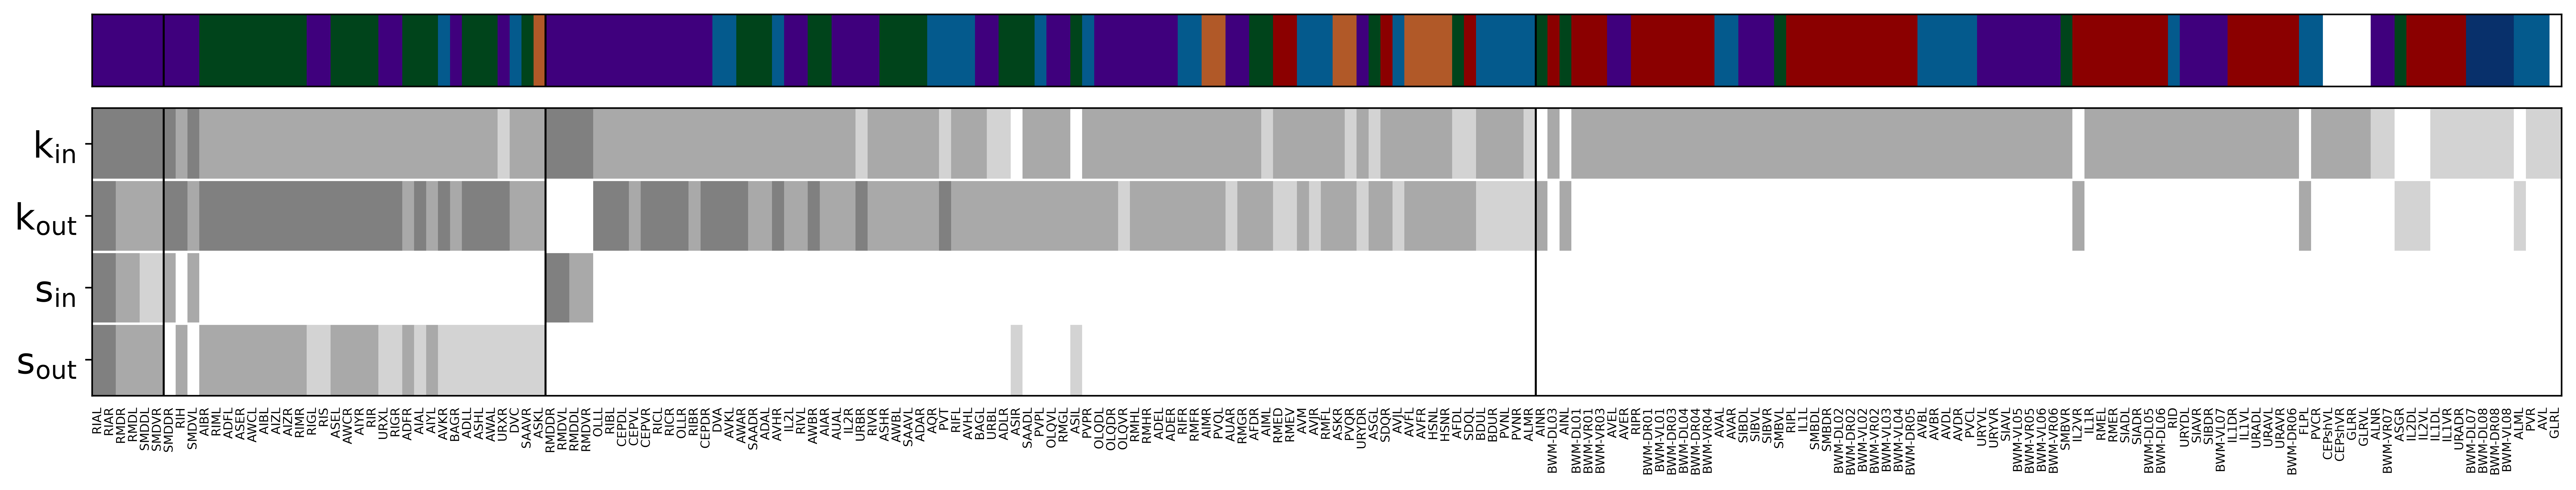

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

core_order = ['kin', 'kout', 'sin', 'sout']
core_order_labels = ['$k_{in}$', '$k_{out}$', '$s_{in}$', '$s_{out}$']
n_cores = len(core_order)

nodes = list(neuron_core_counts.keys())

# Sorting logic
def total_core_types(node):
    return sum(neuron_core_counts[node][c] > 0 for c in core_order)

def total_stage_count(node):
    return sum(neuron_core_counts[node][c] for c in core_order)

def module_name(node):
    sc = union_graph.nodes[node].get('specific_class', None)
    return neuron_to_behavior.get(sc, 'Unknown')

nodes_sorted = sorted(
    nodes,
    key=lambda n: (
        -total_core_types(n),
        -total_stage_count(n),
        module_name(n)
    )
)

# Find separator positions (by number of core-types)
core_type_counts = [total_core_types(n) for n in nodes_sorted]
separator_positions = []
for i in range(1, len(core_type_counts)):
    if core_type_counts[i] != core_type_counts[i - 1]:
        separator_positions.append(i - 0.5)

# Build core-category matrix
core_matrix = np.zeros((n_cores, len(nodes_sorted)), dtype=int)

for i, core in enumerate(core_order):
    for j, node in enumerate(nodes_sorted):
        count = neuron_core_counts[node][core]
        if count == 1:
            core_matrix[i, j] = 1
        elif 2 <= count <= 7:
            core_matrix[i, j] = 2
        elif count == 8:
            core_matrix[i, j] = 3
        else:
            core_matrix[i, j] = 0

cmap = ListedColormap([
    CATEGORY_COLORS['absent'],
    CATEGORY_COLORS['transient'],
    CATEGORY_COLORS['recurrent'],
    CATEGORY_COLORS['persistent']
])


# Module annotation row
module_names = []
specific_class_labels = []

for node in nodes_sorted:
    sc = union_graph.nodes[node].get('specific_class', None)
    specific_class_labels.append(sc if sc is not None else 'Unknown')
    module_names.append(neuron_to_behavior.get(sc, 'Unknown'))

unique_modules = sorted(set(module_names))
module_to_int = {m: i for i, m in enumerate(unique_modules)}
module_row = np.array([[module_to_int[m] for m in module_names]])

module_colors = [behavior_colors.get(m, 'white') for m in unique_modules]
module_cmap = ListedColormap(module_colors)


# Plot (ONLY 2 axes now)
fig, axes = plt.subplots(
    2, 1,
    figsize=(18, 3.5),  # taller to fit rotated labels (but no extra whitespace row)
    gridspec_kw={'height_ratios': [1, 4]},
    dpi=500
)

# Module strip
axes[0].imshow(module_row, aspect='auto', cmap=module_cmap)
axes[0].set_yticks([])
axes[0].set_xticks([])
#axes[0].set_ylabel('Module', fontsize=18)

# Core barcode
axes[1].imshow(core_matrix, aspect='auto', cmap=cmap)
axes[1].set_yticks(range(n_cores))
axes[1].set_yticklabels(core_order_labels, fontsize=18)

# Hairline white gaps between core rows
for y in range(1, n_cores):
    axes[1].axhline(y - 0.5, color='white', lw=1.2)

# Specific class labels on the SAME axis (no extra subplot)
n_cols = len(nodes_sorted)
axes[1].set_xticks(range(n_cols))
axes[1].set_xticklabels(specific_class_labels, rotation=90, fontsize=6, ha='center', va='top')
axes[1].tick_params(axis='x', length=0, pad=6)  # pad controls distance from heatmap

# Vertical separators on both axes
for x in separator_positions:
    axes[0].axvline(x, color='black', lw=1)
    axes[1].axvline(x, color='black', lw=1)

plt.tight_layout()
plt.show()
